In [1]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 🫁 Pneumonia Detection from Chest X-Rays
### Transfer Learning with DenseNet121 + Grad-CAM Explainability

**Goal:** Classify chest X-ray images as NORMAL or PNEUMONIA using fine-tuned DenseNet121, with class-imbalance handling, comprehensive evaluation metrics, and Grad-CAM visualizations for interpretability.

| Section | Description |
|---|---|
| 1 | Setup & Data Download |
| 2 | EDA & Class Distribution |
| 3 | Data Augmentation & Generators |
| 4 | Model Architecture |
| 5 | Phase 1 Training (Frozen Base) |
| 6 | Phase 2 Fine-Tuning |
| 7 | Evaluation & Metrics |
| 8 | Grad-CAM Visualization |
| 9 | Single Image Inference |

## 📦 Cell 1 — Kaggle Setup & Dataset Download

In [2]:
from google.colab import files
import os

# Upload kaggle.json
files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/ --quiet

import zipfile
with zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r') as z:
    z.extractall('/content/chest_xray_dataset')

print('✅ Dataset extracted.')
print(os.listdir('/content/chest_xray_dataset/chest_xray'))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
✅ Dataset extracted.
['train', 'chest_xray', 'val', 'test', '__MACOSX']


## 📊 Cell 2 — Exploratory Data Analysis (EDA)

Image counts:
  train : {'NORMAL': 1341, 'PNEUMONIA': 3875}  |  Total=5216
  val   : {'NORMAL': 8, 'PNEUMONIA': 8}  |  Total=16
  test  : {'NORMAL': 234, 'PNEUMONIA': 390}  |  Total=624


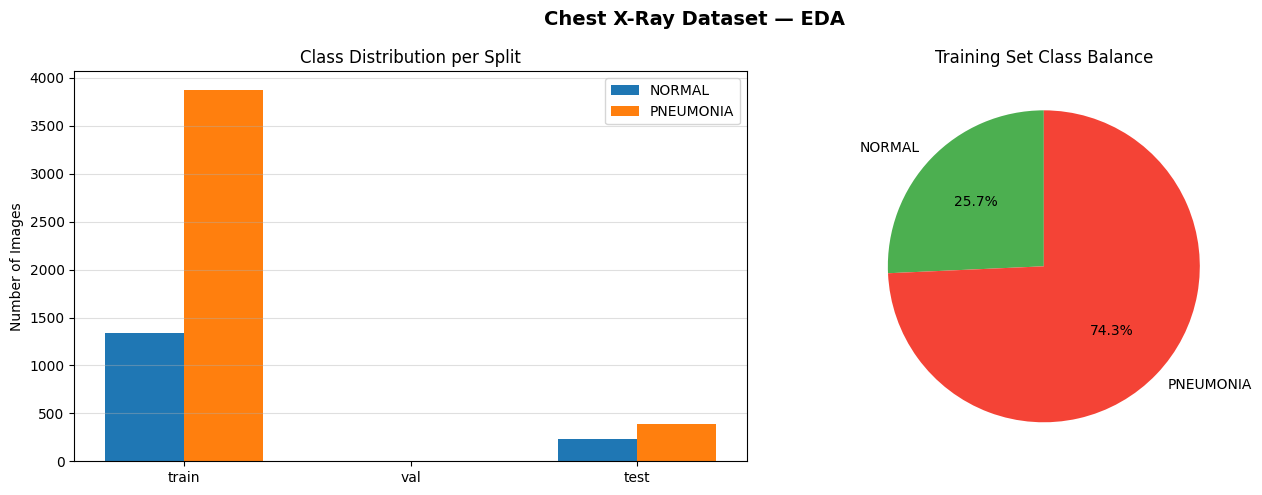

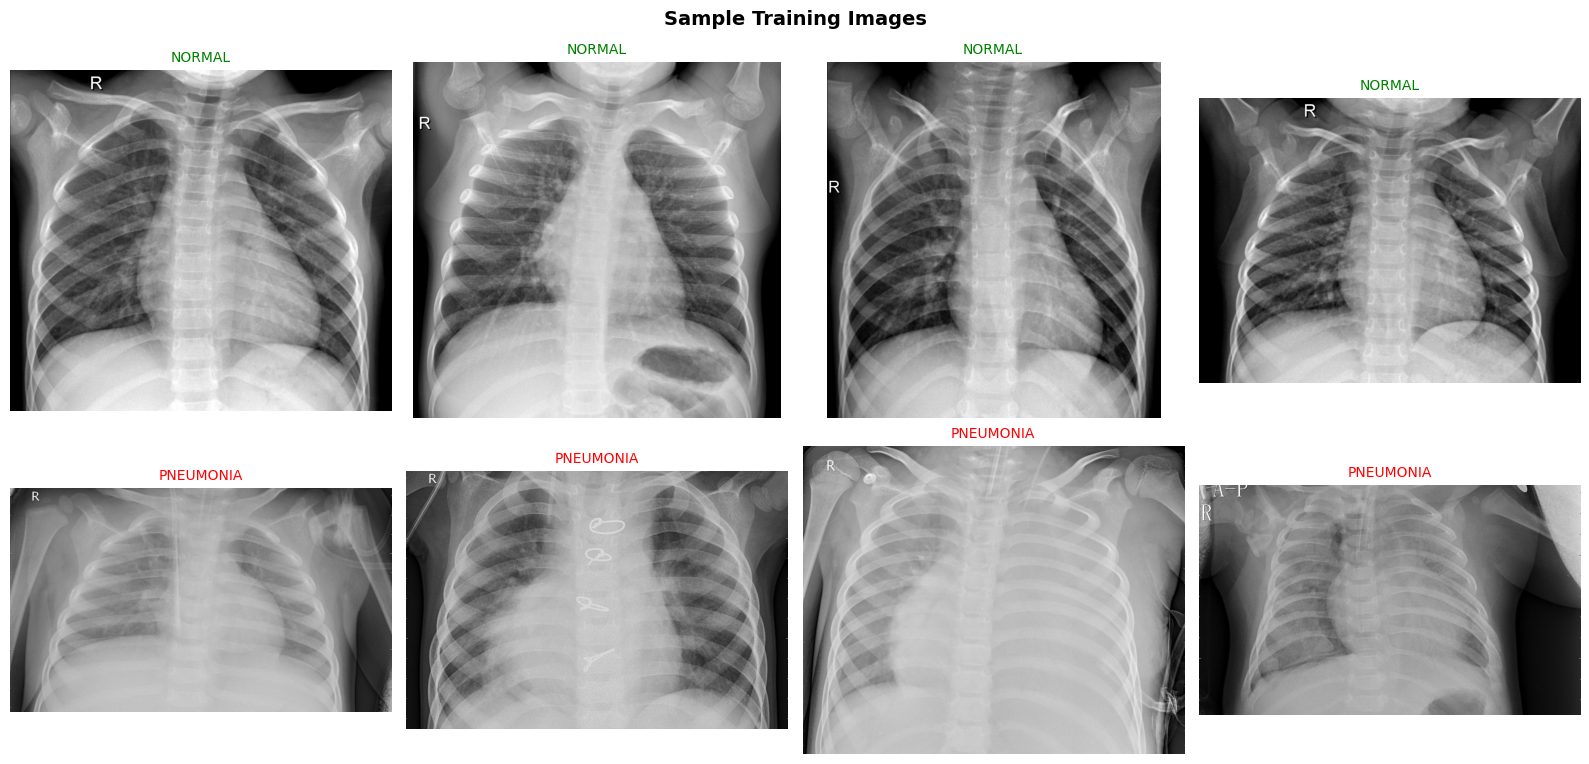

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import random

DATASET_PATH = '/content/chest_xray_dataset/chest_xray'
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

# ── Count images per split and class ──────────────────────────────────────────
counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)
        if os.path.exists(path):
            counts[split][cls] = len(os.listdir(path))
        else:
            counts[split][cls] = 0

print('Image counts:')
for split, cls_counts in counts.items():
    total = sum(cls_counts.values())
    print(f'  {split:6s}: {cls_counts}  |  Total={total}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(splits))
w = 0.35
for i, cls in enumerate(classes):
    vals = [counts[s].get(cls, 0) for s in splits]
    axes[0].bar(x + i * w, vals, width=w, label=cls)
axes[0].set_xticks(x + w / 2)
axes[0].set_xticklabels(splits)
axes[0].set_title('Class Distribution per Split')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# ── Pie chart for training set ─────────────────────────────────────────────────
train_vals = [counts['train'].get(c, 0) for c in classes]
axes[1].pie(train_vals, labels=classes, autopct='%1.1f%%', startangle=90,
            colors=['#4CAF50', '#F44336'])
axes[1].set_title('Training Set Class Balance')

plt.suptitle('Chest X-Ray Dataset — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sample images ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, cls in enumerate(classes):
    img_dir = os.path.join(DATASET_PATH, 'train', cls)
    samples = random.sample(os.listdir(img_dir), 4)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=10,
                                  color='green' if cls == 'NORMAL' else 'red')
        axes[row, col].axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Cell 3 — Configuration & Class Weights

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# ── Hyperparameters ────────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS_P1   = 10    # Phase 1: frozen base
EPOCHS_P2   = 5     # Phase 2: fine-tuning
LR_P1       = 1e-4
LR_P2       = 1e-5
UNFREEZE_FROM = -50  # Unfreeze last 50 layers in fine-tuning

train_dir = os.path.join(DATASET_PATH, 'train')
val_dir   = os.path.join(DATASET_PATH, 'val')
test_dir  = os.path.join(DATASET_PATH, 'test')

# ── Class weights to handle imbalance ─────────────────────────────────────────
# Count training labels
n_normal    = counts['train']['NORMAL']
n_pneumonia = counts['train']['PNEUMONIA']
total_train = n_normal + n_pneumonia

# Sklearn-style balanced weights: total / (n_classes * class_count)
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array([0] * n_normal + [1] * n_pneumonia)
)
class_weights = {0: class_weight_values[0], 1: class_weight_values[1]}
print(f'Class weights: NORMAL={class_weights[0]:.3f}, PNEUMONIA={class_weights[1]:.3f}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

Class weights: NORMAL=1.945, PNEUMONIA=0.673
GPU available: True


## 🔄 Cell 4 — Data Augmentation & Generators

In [5]:
# ── Train generator with augmentation ─────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val/Test generator — NO augmentation, only rescaling ─────────────────────
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# Use the provided val split — avoids data leakage from using train subset as val
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('Class indices:', train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 🏗️ Cell 5 — Model Architecture (DenseNet121 + Custom Head)

In [6]:
# ── Load pretrained DenseNet121 (ImageNet weights) ────────────────────────────
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # Freeze for Phase 1

# ── Custom classification head ────────────────────────────────────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)       # Spatial pooling
x = BatchNormalization()(x)           # Stabilise activations
x = Dense(256, activation='relu')(x)  # Additional capacity
x = Dropout(0.4)(x)                   # Regularisation
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary output

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LR_P1),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Quick summary of trainable params
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
total     = sum(tf.size(w).numpy() for w in model.weights)
print(f'Trainable params: {trainable:,} / Total: {total:,}')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 297,473 / Total: 7,337,025


## 🚀 Cell 6 — Phase 1 Training (Frozen Base)

In [7]:
callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=3,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_model_phase1.keras',
                    monitor='val_auc', save_best_only=True,
                    mode='max', verbose=1)
]

print('Phase 1: Training with frozen DenseNet121 base...')
history_p1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P1,
    class_weight=class_weights,   # Handle imbalance
    callbacks=callbacks_p1
)
print('Phase 1 complete.')

Phase 1: Training with frozen DenseNet121 base...
Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7700 - auc: 0.8420 - loss: 0.4620 - precision: 0.8993 - recall: 0.7784
Epoch 1: val_auc improved from None to 0.89844, saving model to /content/best_model_phase1.keras

Epoch 1: finished saving model to /content/best_model_phase1.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 145s 357ms/step - accuracy: 0.8424 - auc: 0.9293 - loss: 0.3409 - precision: 0.9467 - recall: 0.8348 - val_accuracy: 0.7500 - val_auc: 0.8984 - val_loss: 0.3609 - val_precision: 0.7500 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9099 - auc: 0.9681 - loss: 0.2239 - precision: 0.9749 - recall: 0.9032
Epoch 2: val_auc improved from 0.89844 to 0.93750, saving model to /content/best_model_phase1.keras

Epoch 2: finished saving model to /content/best_model_phase1.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 103s 315ms/step - accuracy: 0.9170 - auc: 0.971

## 🔧 Cell 7 — Phase 2 Fine-Tuning (Partial Unfreeze)

In [8]:
# ── Unfreeze last 50 layers of DenseNet121 ─────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen DenseNet layers: {unfrozen} / {len(base_model.layers)}')

# Recompile with a lower LR to avoid destroying pretrained features
model.compile(
    optimizer=Adam(learning_rate=LR_P2),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_p2 = [
    EarlyStopping(monitor='val_auc', patience=3,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/best_model_phase2.keras',
                    monitor='val_auc', save_best_only=True,
                    mode='max', verbose=1)
]

print('Phase 2: Fine-tuning...')
history_p2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P2,
    class_weight=class_weights,
    callbacks=callbacks_p2
)
print('Fine-tuning complete.')

Unfrozen DenseNet layers: 50 / 427
Phase 2: Fine-tuning...
Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9346 - auc: 0.9829 - loss: 0.1609 - precision: 0.9777 - recall: 0.9338
Epoch 1: val_auc improved from None to 0.96875, saving model to /content/best_model_phase2.keras

Epoch 1: finished saving model to /content/best_model_phase2.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 158s 367ms/step - accuracy: 0.9352 - auc: 0.9823 - loss: 0.1650 - precision: 0.9771 - recall: 0.9347 - val_accuracy: 0.8750 - val_auc: 0.9688 - val_loss: 0.2243 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9417 - auc: 0.9854 - loss: 0.1490 - precision: 0.9847 - recall: 0.9363
Epoch 2: val_auc improved from 0.96875 to 1.00000, saving model to /content/best_model_phase2.keras

Epoch 2: finished saving model to /content/best_model_phase2.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 104s 320ms/step - accuracy: 0.9427 - auc

## 📈 Cell 8 — Training Curves

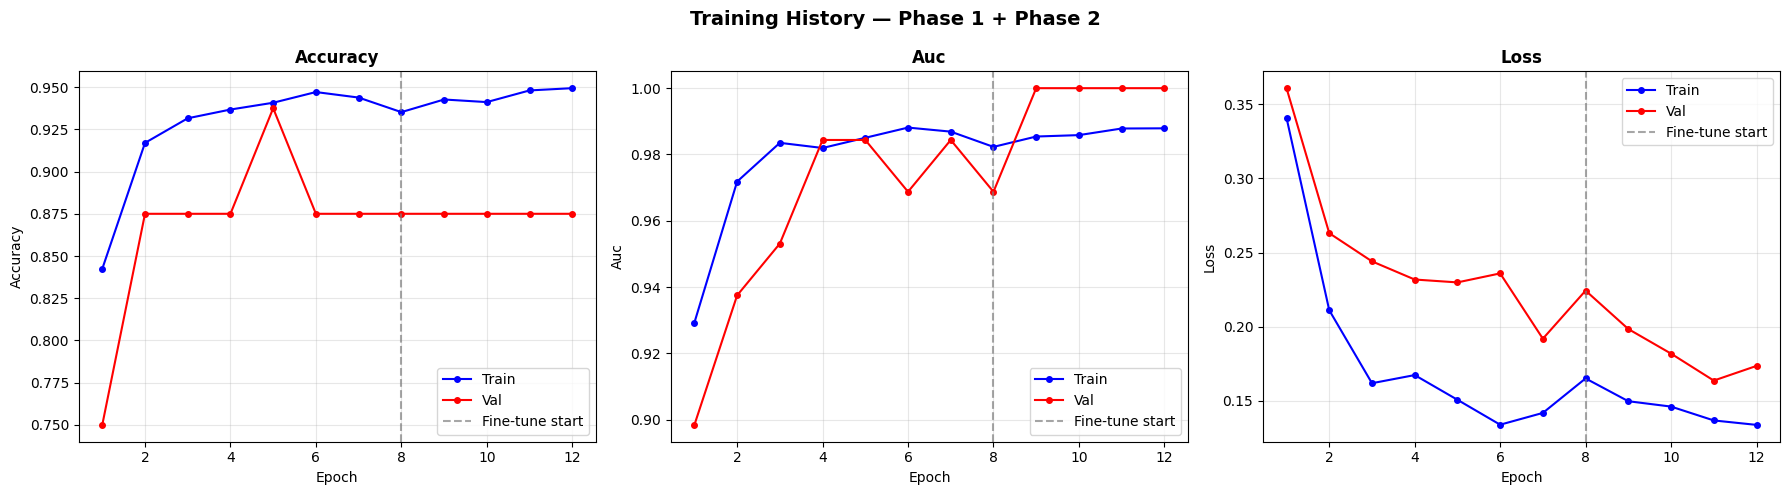

In [9]:
def plot_combined_history(h1, h2, metrics=('accuracy', 'auc', 'loss')):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    for ax, metric in zip(axes, metrics):
        p1_train = h1.history.get(metric, [])
        p1_val   = h1.history.get(f'val_{metric}', [])
        p2_train = h2.history.get(metric, [])
        p2_val   = h2.history.get(f'val_{metric}', [])

        combined_train = p1_train + p2_train
        combined_val   = p1_val   + p2_val
        epochs_range   = range(1, len(combined_train) + 1)
        ft_start       = len(p1_train) + 1  # Fine-tune start epoch

        ax.plot(epochs_range, combined_train, 'b-o', markersize=4, label='Train')
        ax.plot(epochs_range, combined_val,   'r-o', markersize=4, label='Val')
        ax.axvline(ft_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(metric.capitalize(), fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Training History — Phase 1 + Phase 2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_history(history_p1, history_p2)

## 📊 Cell 9 — Comprehensive Evaluation (Confusion Matrix + Classification Report + ROC Curve)

39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.86      0.85      0.86       234
   PNEUMONIA       0.91      0.92      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.89       624
weighted avg       0.89      0.89      0.89       624



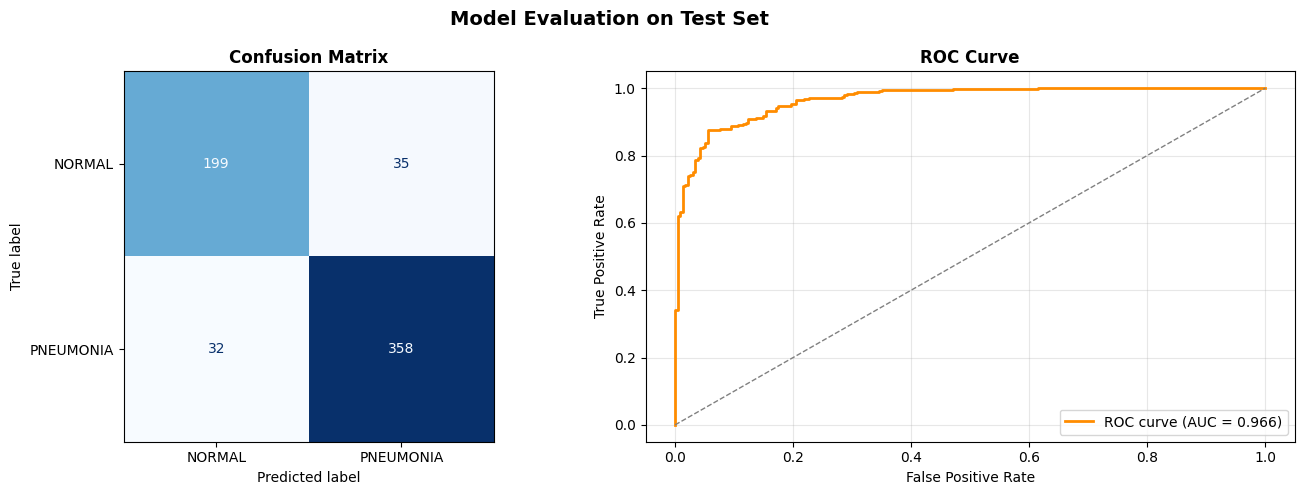


Sensitivity (Recall for Pneumonia): 0.9179
Specificity (Recall for Normal):    0.8504
AUC-ROC:                            0.9663


In [10]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, ConfusionMatrixDisplay)
import itertools

# ── Predictions ───────────────────────────────────────────────────────────────
test_data.reset()
y_pred_prob = model.predict(test_data, verbose=1)
y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()
y_true      = test_data.classes
class_names = list(test_data.class_indices.keys())

# ── Metrics printout ─────────────────────────────────────────────────────────
print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('Model Evaluation on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key metrics summary ───────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f'\nSensitivity (Recall for Pneumonia): {sensitivity:.4f}')
print(f'Specificity (Recall for Normal):    {specificity:.4f}')
print(f'AUC-ROC:                            {roc_auc:.4f}')

## 🔍 Cell 10 — Grad-CAM Visualization (Explainability)


Grad-CAM for a NORMAL image:


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


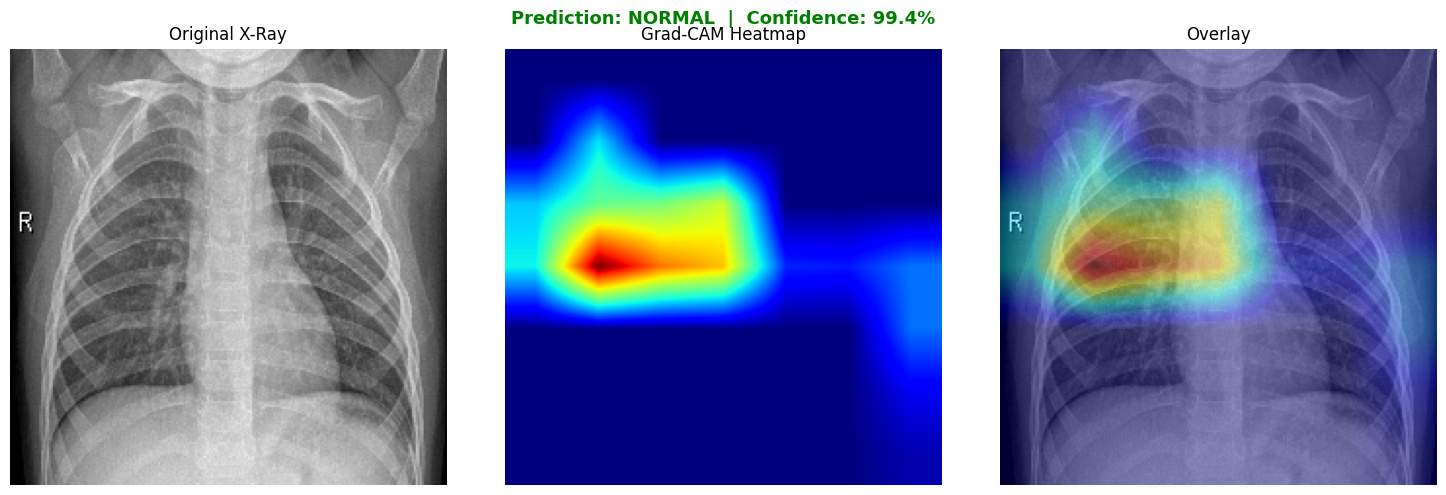


Grad-CAM for a PNEUMONIA image:


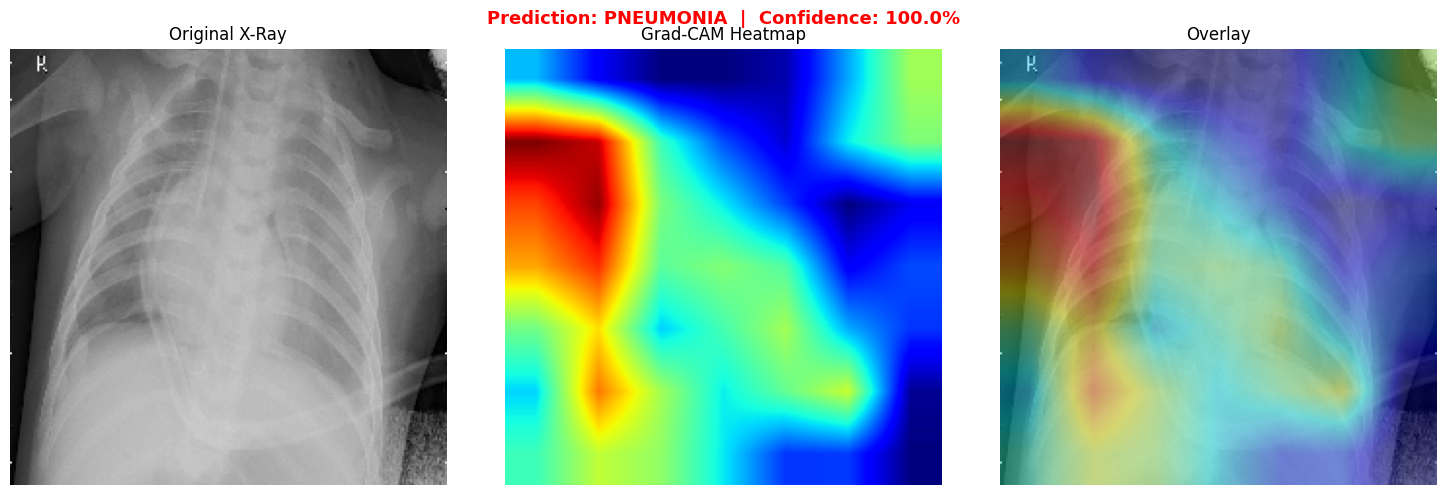

In [11]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

# ── Grad-CAM implementation ───────────────────────────────────────────────────
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    """
    Compute Grad-CAM heatmap for a given image and the last conv layer.
    Returns a 2D heatmap normalised to [0, 1].
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads     = tape.gradient(loss, conv_outputs)          # (1, H, W, C)
    pooled    = tf.reduce_mean(grads, axis=(0, 1, 2))      # (C,)
    heatmap   = conv_outputs[0] @ pooled[..., tf.newaxis]  # (H, W, 1)
    heatmap   = tf.squeeze(heatmap)                         # (H, W)
    heatmap   = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, model, last_conv_layer='bn'):
    """Load image, compute Grad-CAM, and display side-by-side overlay."""
    # Prepare input
    img  = keras_image.load_img(img_path, target_size=(224, 224))
    arr  = keras_image.img_to_array(img) / 255.0
    inp  = np.expand_dims(arr, axis=0)

    # Prediction
    pred  = model.predict(inp, verbose=0)[0][0]
    label = 'PNEUMONIA' if pred >= 0.5 else 'NORMAL'
    conf  = pred if pred >= 0.5 else 1 - pred

    # Heatmap
    heatmap = get_gradcam_heatmap(model, inp, last_conv_layer)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (0.6 * arr + 0.4 * heatmap_colored).clip(0, 1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(arr);         axes[0].set_title('Original X-Ray');    axes[0].axis('off')
    axes[1].imshow(heatmap_resized, cmap='jet'); axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay);     axes[2].set_title('Overlay');           axes[2].axis('off')

    color = 'red' if label == 'PNEUMONIA' else 'green'
    plt.suptitle(f'Prediction: {label}  |  Confidence: {conf*100:.1f}%',
                 fontsize=13, fontweight='bold', color=color)
    plt.tight_layout()
    plt.savefig('/content/gradcam_output.png', dpi=150, bbox_inches='tight')
    plt.show()
    return label, conf


# ── Demo: pick a random test image ────────────────────────────────────────────
# DenseNet121's last conv layer is named 'bn' (the final batch norm)
# Use model.layers to inspect if needed
LAST_CONV = 'bn'   # Final BatchNorm in DenseNet121 acts as last feature map

for cls in classes:
    sample_dir = os.path.join(test_dir, cls)
    if os.path.exists(sample_dir):
        sample_img = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))
        print(f'\nGrad-CAM for a {cls} image:')
        overlay_gradcam(sample_img, model, last_conv_layer=LAST_CONV)

## 💾 Cell 11 — Save Model

In [12]:
# Save in modern Keras format (recommended over .h5)
model.save('/content/pneumonia_densenet121_final.keras')
print('✅ Model saved as pneumonia_densenet121_final.keras')

# Also save weights only (lightweight checkpoint)
model.save_weights('/content/pneumonia_weights.weights.h5')
print('✅ Weights saved.')

✅ Model saved as pneumonia_densenet121_final.keras
✅ Weights saved.


## 🩻 Cell 12 — Single Image Inference (Upload & Predict)

📤 Upload a chest X-ray image (.jpg / .jpeg / .png):


Saving person1005_virus_1688.jpeg to person1005_virus_1688.jpeg

Prediction : 🦠 PNEUMONIA
Confidence : 87.53%
Raw score  : 0.8753  (≥0.5 → PNEUMONIA)


/tmp/ipykernel_768/2066689984.py:40: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/2066689984.py:41: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/single_inference.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


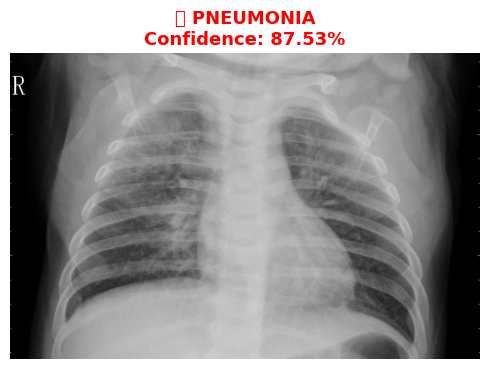

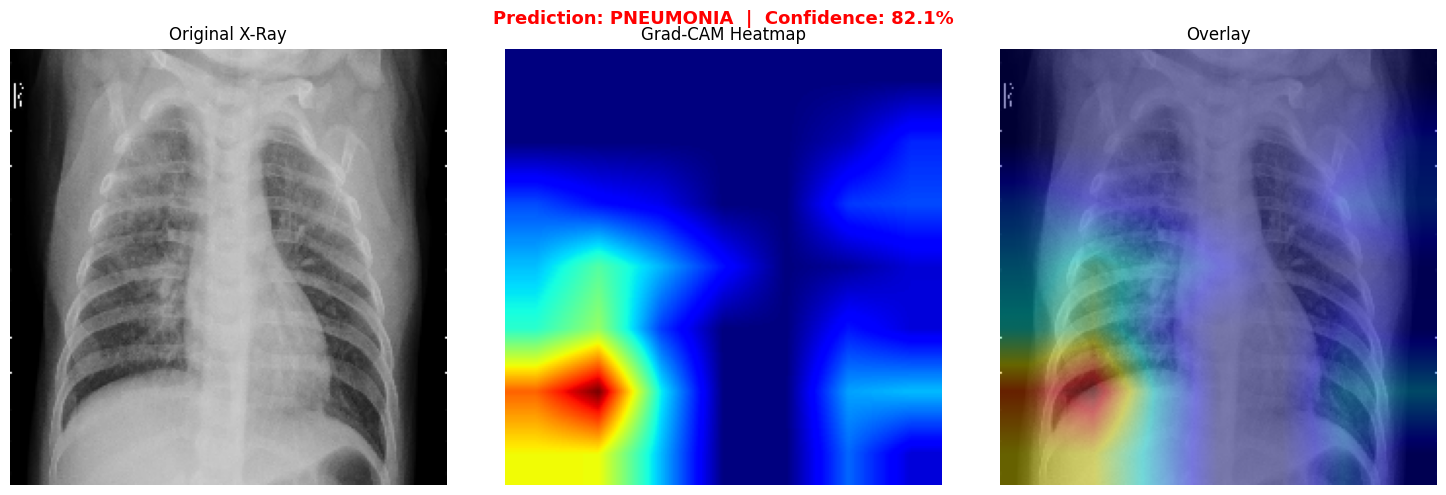

('PNEUMONIA', np.float32(0.8209544))

In [14]:
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print('📤 Upload a chest X-ray image (.jpg / .jpeg / .png):')
uploaded = files.upload()

# Pick image file
image_file = [f for f in uploaded
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
if not image_file:
    raise ValueError('No image file found in upload.')
image_file = image_file[0]

# Prepare image
img         = Image.open(image_file).convert('RGB')
img_resized = img.resize((224, 224))
img_array   = keras_image.img_to_array(img_resized) / 255.0
img_input   = np.expand_dims(img_array, axis=0)

# Predict
prob   = model.predict(img_input, verbose=0)[0][0]
label  = '🦠 PNEUMONIA' if prob >= 0.5 else '✅ NORMAL'
conf   = prob if prob >= 0.5 else 1 - prob
color  = 'red' if prob >= 0.5 else 'green'

print(f'\nPrediction : {label}')
print(f'Confidence : {conf * 100:.2f}%')
print(f'Raw score  : {prob:.4f}  (≥0.5 → PNEUMONIA)')

# Visualise
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f'{label}\nConfidence: {conf * 100:.2f}%', fontsize=13,
          fontweight='bold', color=color)
plt.tight_layout()
plt.savefig('/content/single_inference.png', dpi=150, bbox_inches='tight')
plt.show()

# Optional Grad-CAM on the uploaded image
overlay_gradcam(image_file, model, last_conv_layer=LAST_CONV)